# Lab 2.1 · Data Profiling และทำความสะอาดข้อมูลด้วย AI

**คาบ 2 · เสาร์ 27 ก.ย. 2026 · 45 นาที**

ข้อมูล `sales_raw.csv` คือยอดขายชุดเดียวกับที่ใช้ใน Lab 1 แต่ดึงมาจากระบบ POS โดยตรง จึงมีปัญหาปนมา เป้าหมายคือได้ `sales_clean.csv` ที่ถูกต้อง แล้วนำไปใช้ต่อใน Dashboard ของ Lab 2.2

| ขั้น | เวลา | ทำอะไร |
|---|---|---|
| 1 | 5 นาที | โหลดและดูข้อมูลครั้งแรก |
| 2 | 10 นาที | Profiling: ให้ AI หาปัญหา **แต่ยังไม่แก้** แล้วตรวจคำตอบ |
| 3 | 5 นาที | ตัดสินใจว่าจะจัดการแต่ละปัญหาอย่างไร |
| 4 | 20 นาที | ทำความสะอาดด้วย AI |
| 5–6 | 5 นาที | Verify และ export |

**วิธีใช้กับ AI:** ใช้ Gemini ที่อยู่ใน Colab หรือคัดลอก prompt ไปใช้กับ Claude / ChatGPT แล้ววางโค้ดกลับมา

## ขั้นที่ 0 · เตรียมเครื่องมือ
รันเซลล์นี้ก่อน (ไม่ต้องแก้) เซลล์นี้มีฟังก์ชัน `check()` สำหรับตรวจคำตอบโดยไม่เฉลยตัวเลข และ `validate()` สำหรับตรวจข้อมูลที่ทำความสะอาดแล้ว

In [ ]:
# ===== เซลล์ตัวช่วยของ Lab 2.1 · รันก่อน ไม่ต้องแก้ =====
import base64, json, os, re
import pandas as pd

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

_EXP = json.loads(base64.b64decode(
    "eyJyYXdfcm93cyI6IDUzMzU3LCAiZHVwX3Jvd3MiOiAyNjUsICJiYWRfZGF0ZXRpbWUiOiAxMTYyLCAiYmFkX2JyYW5jaCI6IDEwNzEsICJwcmljZV9ub3RfbnVtYmVyIjogNjEsICJwcmljZV9uZWdhdGl2ZSI6IDI1LCAicXR5X3plcm8iOiAyMCwgIm1pc3NpbmdfcHJvZHVjdCI6IDE1fQ=="
).decode())
_LABEL = {
    "raw_rows": "จำนวนแถวทั้งหมด",
    "dup_rows": "แถวที่ซ้ำกันทุกคอลัมน์ (ไม่นับแถวแรก)",
    "bad_datetime": "datetime ที่ไม่ใช่รูปแบบ ค.ศ. มาตรฐาน (YYYY-MM-DDT…)",
    "bad_branch": "ชื่อสาขาที่ไม่ใช่ 5 ชื่อมาตรฐาน",
    "price_not_number": "unit_price ที่แปลงเป็นตัวเลขไม่ได้",
    "price_negative": "unit_price ที่ติดลบ",
    "qty_zero": "qty เท่ากับ 0",
    "missing_product": "product_id ว่าง",
}
_HINT = {
    "dup_rows": "ใช้ df.duplicated() ทั้งแถว ไม่ใช่ duplicated('order_id') เพราะ 1 บิลมีหลายแถว",
    "bad_datetime": "นับทั้งปี พ.ศ. (25xx-…) และรูปแบบ DD/MM/YYYY รวมกัน",
    "bad_branch": "ช่องว่างท้ายชื่อก็นับว่าไม่มาตรฐาน ลองดู df['branch'].value_counts()",
    "price_not_number": "ลอง pd.to_numeric(df['unit_price'], errors='coerce').isna()",
    "price_negative": "ต้องแปลงเป็นตัวเลขก่อนจึงเทียบ < 0 ได้",
    "missing_product": "อ่านไฟล์ด้วย keep_default_na=False ค่าว่างจึงเป็น '' ไม่ใช่ NaN",
}
STD_BRANCHES = ["สยาม", "สีลม", "อารีย์", "บางนา", "มหาวิทยาลัย"]


def check(name, value):
    """เทียบคำตอบกับเฉลยโดยไม่บอกตัวเลข"""
    exp = _EXP[name]
    label = _LABEL[name]
    if value is None:
        print(f"⬜ {label}: ยังไม่ได้ใส่ค่า")
    elif int(value) == exp:
        print(f"✅ {label}: {int(value):,}")
    elif abs(int(value) - exp) <= max(2, exp * 0.03):
        print(f"🟡 {label}: {int(value):,} ใกล้แล้ว แต่ยังไม่ตรง · {_HINT.get(name, 'ตรวจเงื่อนไขอีกครั้ง')}")
    else:
        print(f"❌ {label}: {int(value):,} ยังไม่ถูก · {_HINT.get(name, 'ตรวจเงื่อนไขอีกครั้ง')}")


def load_csv(name):
    """อ่าน CSV ทุกคอลัมน์เป็นข้อความ ถ้าไม่มีไฟล์จะให้อัปโหลด (Google Colab)"""
    if not os.path.exists(name):
        try:
            from google.colab import files
            print(f"ไม่พบ {name} กรุณาอัปโหลดไฟล์")
            files.upload()
        except ImportError:
            raise FileNotFoundError(f"ไม่พบไฟล์ {name} ให้วางไฟล์ไว้โฟลเดอร์เดียวกับ notebook")
    return pd.read_csv(name, dtype=str, keep_default_na=False)


def validate(clean, reference="sales.csv"):
    """ตรวจ sales_clean ว่าพร้อมใช้ใน Dashboard และเทียบกับไฟล์อ้างอิง"""
    ok = True
    def rep(passed, msg):
        nonlocal ok
        ok &= bool(passed)
        print(("✅ " if passed else "❌ ") + msg)

    cols = ["order_id", "datetime", "branch", "product_id", "qty", "unit_price",
            "customer_id", "payment_method", "channel"]
    rep(list(clean.columns) == cols, "คอลัมน์ครบและเรียงเหมือน sales.csv")
    dt = clean["datetime"].astype(str)
    bad_dt = ~dt.str.match(r"^20(25|26)-\d\d-\d\dT\d\d:\d\d:\d\d\+07:00$")
    rep(bad_dt.sum() == 0, f"datetime เป็น YYYY-MM-DDTHH:MM:SS+07:00 ทุกแถว (ผิด {bad_dt.sum():,} แถว)")
    bad_b = ~clean["branch"].isin(STD_BRANCHES)
    rep(bad_b.sum() == 0, f"ชื่อสาขาเหลือ 5 ชื่อมาตรฐาน (ผิด {bad_b.sum():,} แถว)")
    price = pd.to_numeric(clean["unit_price"], errors="coerce")
    rep(price.notna().all() and (price > 0).all(), "unit_price เป็นตัวเลขมากกว่า 0 ทุกแถว")
    qty = pd.to_numeric(clean["qty"], errors="coerce")
    rep(qty.notna().all() and (qty > 0).all(), "qty เป็นตัวเลขมากกว่า 0 ทุกแถว")
    rep((clean["product_id"].astype(str).str.match(r"^P0[0-4]\d$")).all(), "product_id ไม่ว่าง และอยู่ในช่วง P001–P040")
    rep(clean.duplicated().sum() == 0, "ไม่มีแถวซ้ำ")

    if os.path.exists(reference):
        ref = pd.read_csv(reference, dtype=str, keep_default_na=False)
        key = ["order_id", "product_id"]
        m = ref.merge(clean.astype(str), on=key, how="outer", suffixes=("_ref", ""), indicator=True)
        only_ref = (m["_merge"] == "left_only").sum()
        only_clean = (m["_merge"] == "right_only").sum()
        both = m[m["_merge"] == "both"]
        diff_min = (both["datetime_ref"].str[:16] != both["datetime"].str[:16]).sum()
        diff_branch = (both["branch_ref"] != both["branch"]).sum()
        rev = lambda d: (pd.to_numeric(d["qty"]) * pd.to_numeric(d["unit_price"])).sum()
        print("\n— เทียบกับไฟล์อ้างอิง sales.csv —")
        print(f"แถวที่คุณตัดทิ้ง: {only_ref:,} · แถวเกิน: {only_clean:,}")
        print(f"วันเวลาไม่ตรง (ระดับนาที): {diff_min:,} · สาขาไม่ตรง: {diff_branch:,}")
        print(f"ยอดขายรวม: ของคุณ ฿{rev(clean):,.0f} · อ้างอิง ฿{rev(ref):,.0f} · ต่าง ฿{rev(clean) - rev(ref):,.0f}")
        rep(only_clean == 0 and diff_min == 0 and diff_branch == 0, "ทุกแถวที่เก็บไว้ตรงกับข้อมูลอ้างอิง")
        rep(only_ref <= 100, f"ตัดทิ้งไม่เกิน 100 แถว (ตัดไป {only_ref:,}) · ถ้าเกิน ตรวจว่าไม่ได้ลบแถวซ้ำด้วย order_id หรือทิ้งแถวที่แก้ได้")
    print("\n🎉 พร้อม export" if ok else "\nยังมีจุดต้องแก้ ลองส่งข้อความ ❌ ให้ AI ช่วยหาสาเหตุ")
    return ok

## ขั้นที่ 1 · ดูข้อมูลครั้งแรก (5 นาที)

อัปโหลด `sales_raw.csv` และ `sales.csv` จากโฟลเดอร์ `data/` (ถ้าใช้ Colab จะมีปุ่มให้อัปโหลด)

เราอ่าน **ทุกคอลัมน์เป็นข้อความ** โดยตั้งใจ เพราะถ้าให้ pandas เดาชนิดข้อมูลเอง ปัญหาบางอย่างจะถูกซ่อน เช่น ค่าว่างกลายเป็น NaN หรือตัวเลขที่ปนข้อความทำให้ทั้งคอลัมน์กลายเป็นข้อความโดยไม่บอกเรา

In [ ]:
df = load_csv("sales_raw.csv")
load_csv("sales.csv")  # ไฟล์อ้างอิงสำหรับ validate() ในขั้นที่ 5
print(f"{len(df):,} แถว × {df.shape[1]} คอลัมน์")
df.head(8)

ไม่พบ sales.csv กรุณาอัปโหลดไฟล์


Saving sales.csv to sales.csv
53,357 แถว × 9 คอลัมน์


,order_id,datetime,branch,product_id,qty,unit_price,customer_id,payment_method,channel
0,ORD0000001,2025-04-01T17:09:07+07:00,สยาม,P015,1,60,,QR พร้อมเพย์,หน้าร้าน
1,ORD0000002,2025-04-01T11:14:14+07:00,สยาม,P017,1,55,,QR พร้อมเพย์,หน้าร้าน
2,ORD0000002,2025-04-01T11:14:14+07:00,สยาม,P002,1,65,,บัตรเครดิต,หน้าร้าน
3,ORD0000003,2025-04-01T16:11:32+07:00,สยาม,P037,1,95,,QR พร้อมเพย์,หน้าร้าน
4,ORD0000003,2025-04-01T16:11:32+07:00,สยาม,P028,1,65,,บัตรเครดิต,หน้าร้าน
5,ORD0000004,2025-04-01T14:19:21+07:00,สยาม,P004,2,75,,LINE MAN,เดลิเวอรี
6,ORD0000005,2025-04-01T15:43:41+07:00,สยาม,P002,1,65,,เงินสด,หน้าร้าน
7,ORD0000006,2025-04-01T15:03:46+07:00,สยาม,P004,1,75,,Grab,เดลิเวอรี


**คำถามชวนคิด:** ข้อมูลนี้มีกี่แถวมากกว่า `sales.csv` ของ Lab 1 (53,092 แถว) และคุณเดาว่าแถวที่เกินมาจากอะไร

## ขั้นที่ 2 · Profiling: หาปัญหาก่อน ยังไม่แก้ (10 นาที)

**Prompt**
```
ช่วยทำ data profiling ของ DataFrame df ด้วย pandas (ทุกคอลัมน์เป็น str ค่าว่างเป็น "")
- จำนวนค่าว่างและค่าไม่ซ้ำของแต่ละคอลัมน์
- จำนวนแถวที่ซ้ำกันทุกคอลัมน์
- จำนวน datetime ที่ไม่ใช่รูปแบบ YYYY-MM-DDT... ปี ค.ศ. พร้อมตัวอย่าง
- ชื่อสาขาทั้งหมดพร้อมจำนวนแถว
- จำนวน unit_price ที่แปลงเป็นตัวเลขไม่ได้ พร้อมตัวอย่าง และจำนวนที่ติดลบ
- จำนวนแถว qty = 0 และ product_id ว่าง
เก็บจำนวนแต่ละข้อไว้ในตัวแปร n_dup, n_bad_dt, n_bad_branch, n_price_text, n_price_neg, n_qty_zero, n_missing_product
อย่าแก้ข้อมูล ให้รายงานอย่างเดียว
```
ทำไมต้อง “รายงานก่อน แก้ทีหลัง”: ถ้าสั่งแก้ทันที AI อาจลบหรือเปลี่ยนข้อมูลเงียบ ๆ โดยเราไม่รู้ว่าเปลี่ยนอะไรไปบ้าง

In [ ]:
# วางโค้ดที่ AI เขียนให้ที่นี่ แล้วรัน
# อ่านผลลัพธ์ก่อน อย่าเพิ่งแก้ข้อมูล
# ===== ขั้นที่ 2 · Data profiling (รายงานอย่างเดียว ไม่แก้ df) =====
STD_BRANCHES = ["สยาม", "สีลม", "อารีย์", "บางนา", "มหาวิทยาลัย"]

print(f"จำนวนแถวทั้งหมด: {len(df):,}\n")

# 1) ค่าว่างและค่าไม่ซ้ำของแต่ละคอลัมน์ (ค่าว่าง = "" หรือมีแต่ช่องว่าง)
overview = pd.DataFrame({
    "ค่าว่าง": (df.apply(lambda s: s.str.strip()) == "").sum(),
    "ค่าไม่ซ้ำ": df.nunique(),
})
print("1) ค่าว่าง / ค่าไม่ซ้ำ ต่อคอลัมน์")
print(overview, "\n")

# 2) แถวที่ซ้ำกันทุกคอลัมน์ (ไม่นับแถวแรก) — ห้ามใช้ order_id อย่างเดียว เพราะ 1 บิลมีหลายแถว
n_dup = int(df.duplicated().sum())
print(f"2) แถวซ้ำทุกคอลัมน์: {n_dup:,}\n")

# 3) datetime ที่ไม่ใช่ YYYY-MM-DDT... ปี ค.ศ. (ปี 20xx)
bad_dt = ~df["datetime"].str.match(r"^20\d{2}-\d{2}-\d{2}T")
n_bad_dt = int(bad_dt.sum())
print(f"3) datetime ผิดรูปแบบ: {n_bad_dt:,}")
# จัดกลุ่มตาม "รูปร่าง" (แทนตัวเลขด้วย 9) จะเห็นว่ามีกี่แบบ
print(df.loc[bad_dt, "datetime"].str.replace(r"\d", "9", regex=True).value_counts())
print("ตัวอย่าง:", df.loc[bad_dt, "datetime"].drop_duplicates().head(5).tolist(), "\n")

# 4) ชื่อสาขาทั้งหมด (ใช้ repr ให้เห็นช่องว่างท้ายชื่อ)
branch_counts = df["branch"].value_counts()
branch_counts.index = [repr(b) for b in branch_counts.index]
print("4) ชื่อสาขาทั้งหมด")
print(branch_counts)
n_bad_branch = int((~df["branch"].isin(STD_BRANCHES)).sum())
print(f"ไม่ใช่ 5 ชื่อมาตรฐาน: {n_bad_branch:,}\n")

# 5) unit_price ที่แปลงเป็นตัวเลขไม่ได้ และที่ติดลบ
price = pd.to_numeric(df["unit_price"], errors="coerce")
price_text = price.isna()
n_price_text = int(price_text.sum())
n_price_neg = int((price < 0).sum())
print(f"5) unit_price แปลงเป็นตัวเลขไม่ได้: {n_price_text:,}")
print("ตัวอย่าง:", df.loc[price_text, "unit_price"].drop_duplicates().head(5).tolist())
print(f"unit_price ติดลบ: {n_price_neg:,}")
print("ตัวอย่าง:", df.loc[price < 0, "unit_price"].drop_duplicates().head(5).tolist(), "\n")

# 6) qty = 0 และ product_id ว่าง
qty = pd.to_numeric(df["qty"], errors="coerce")
n_qty_zero = int((qty == 0).sum())
n_missing_product = int((df["product_id"].str.strip() == "").sum())
print(f"6) qty = 0: {n_qty_zero:,} · product_id ว่าง: {n_missing_product:,}\n")

# สรุป
summary = pd.Series({
    "n_dup": n_dup, "n_bad_dt": n_bad_dt, "n_bad_branch": n_bad_branch,
    "n_price_text": n_price_text, "n_price_neg": n_price_neg,
    "n_qty_zero": n_qty_zero, "n_missing_product": n_missing_product,
})
print("สรุป")
print(summary)

จำนวนแถวทั้งหมด: 53,357

1) ค่าว่าง / ค่าไม่ซ้ำ ต่อคอลัมน์
                ค่าว่าง  ค่าไม่ซ้ำ
order_id              0      34791
datetime              0      35456
branch                0         16
product_id           15         41
qty                   0          4
unit_price            0         49
customer_id       28652       2508
payment_method        0          5
channel               0          2 

2) แถวซ้ำทุกคอลัมน์: 265

3) datetime ผิดรูปแบบ: 1,162
datetime
9999-99-99T99:99:99+99:99    630
99/99/9999 99:99             532
Name: count, dtype: int64
ตัวอย่าง: ['2568-04-01T15:18:34+07:00', '2568-04-01T11:22:40+07:00', '2568-04-01T08:14:50+07:00', '01/04/2025 10:54', '2568-04-02T08:47:16+07:00'] 

4) ชื่อสาขาทั้งหมด
'สยาม'           14491
'สีลม'           11620
'บางนา'          10526
'มหาวิทยาลัย'     9313
'อารีย์'          6336
'สีลม '            134
'Silom'            122
'Bangna'           111
'Siam'             108
'บางนา '           103
'มหาลัย'            98
'สยาม '     

### ✔️ ตรวจคำตอบ
ได้ ✅ ครบ 8 ข้อแล้วค่อยไปขั้นต่อไป ถ้าได้ 🟡 หรือ ❌ ให้อ่านคำใบ้แล้วสั่ง AI แก้โค้ด profiling

In [ ]:
# ใส่ตัวเลขจากผลลัพธ์ด้านบน (ใส่เป็นตัวแปรหรือพิมพ์ตัวเลขก็ได้) แล้วรันเพื่อตรวจ
n_dup = 265              # แถวที่ซ้ำกันทุกคอลัมน์
n_bad_dt = 1162           # datetime ที่ไม่ใช่ YYYY-MM-DDT… ปี ค.ศ.
n_bad_branch = 1071       # ชื่อสาขาที่ไม่ใช่ 5 ชื่อมาตรฐาน
n_price_text = 61       # unit_price ที่แปลงเป็นตัวเลขไม่ได้
n_price_neg = 25        # unit_price ติดลบ
n_qty_zero = 20         # qty = 0
n_missing_product = 15  # product_id ว่าง

check("raw_rows", len(df))
check("dup_rows", n_dup)
check("bad_datetime", n_bad_dt)
check("bad_branch", n_bad_branch)
check("price_not_number", n_price_text)
check("price_negative", n_price_neg)
check("qty_zero", n_qty_zero)
check("missing_product", n_missing_product)

✅ จำนวนแถวทั้งหมด: 53,357
✅ แถวที่ซ้ำกันทุกคอลัมน์ (ไม่นับแถวแรก): 265
✅ datetime ที่ไม่ใช่รูปแบบ ค.ศ. มาตรฐาน (YYYY-MM-DDT…): 1,162
✅ ชื่อสาขาที่ไม่ใช่ 5 ชื่อมาตรฐาน: 1,071
✅ unit_price ที่แปลงเป็นตัวเลขไม่ได้: 61
✅ unit_price ที่ติดลบ: 25
✅ qty เท่ากับ 0: 20
✅ product_id ว่าง: 15


## ขั้นที่ 3 · ตัดสินใจก่อนลงมือ (5 นาที · คุยกับเพื่อนข้าง ๆ)

AI เสนอวิธีแก้ได้ แต่ **คนที่รู้ธุรกิจต้องเป็นคนตัดสิน** ดับเบิลคลิกเซลล์นี้เพื่อกรอกตาราง

| ปัญหา | ทางเลือก | ตัดสินใจ | เหตุผล |
|---|---|---|---|
| แถวซ้ำทุกคอลัมน์ | ลบ / เก็บ | | |
| วันที่ พ.ศ. และ DD/MM/YYYY | แปลง / ลบ | | |
| ชื่อสาขาสะกดต่าง | map เป็นชื่อมาตรฐาน / ลบ | | |
| ราคามีคำว่า “บาท” | ตัดคำแล้วแปลง / ลบ | | |
| ราคาติดลบ | ลบ / แปลงเป็นบวก / เก็บไว้เป็นการคืนเงิน | | |
| qty = 0 | ลบ / เก็บ | | |
| product_id ว่าง | ลบ / เดาจากราคา | | |

> ข้อมูลเพิ่มเติมจากร้าน (ผู้สอนเฉลยเมื่อมีคนถาม): ฝ่ายบัญชียืนยันว่า **ไม่มีการคืนเงินในระบบ POS นี้** · ทีม POS ยืนยันว่า **“ม.” คือสาขามหาวิทยาลัย** · qty = 0 คือ **บิลที่ยกเลิก**

## ขั้นที่ 4 · ทำความสะอาดด้วย AI (20 นาที)

**Prompt ตั้งต้น** (แก้ส่วนการตัดสินใจให้ตรงกับตารางของคุณ)

```
เขียนโค้ด pandas ทำความสะอาด df (อ่านมาเป็น str ทุกคอลัมน์ ค่าว่างเป็น "")
- ทำงานบน clean = df.copy() ห้ามแก้ df
- แยกแต่ละปัญหาเป็นขั้นตอนชัดเจน และเก็บ log เป็นรายการ (ขั้นตอน, จำนวนแถวที่กระทบ, การตัดสินใจ)
- ลบแถวที่ซ้ำกันทุกคอลัมน์ (ห้ามใช้ order_id อย่างเดียว เพราะ 1 บิลมีหลายแถว)
- แปลง datetime ทุกแถวเป็นรูปแบบ YYYY-MM-DDTHH:MM:SS+07:00 ปี ค.ศ.
  ต้องรองรับ ISO ปี ค.ศ., ISO ปี พ.ศ. และ DD/MM/YYYY HH:MM (ซึ่งอาจเป็นปี พ.ศ. ด้วย) ถ้าไม่มีวินาทีให้ใส่ 00
- ตัดช่องว่างชื่อสาขา แล้ว map ให้เหลือ: สยาม, สีลม, อารีย์, บางนา, มหาวิทยาลัย
- unit_price: ตัดคำว่า "บาท" แปลงเป็นตัวเลข ราคาติดลบให้ [ตามที่ตัดสินใจ]
- ลบแถว qty = 0 และแถว product_id ว่าง
- ผลลัพธ์ต้องมีคอลัมน์และลำดับเหมือนเดิม unit_price เป็นจำนวนเต็ม
- สุดท้ายแสดง log เป็นตาราง และจำนวนแถวก่อน/หลัง
```

**กับดักที่ต้องระวัง** ถ้า `validate()` ขึ้น ❌ ให้ลองดูสามจุดนี้ก่อน
1. มีวันที่ **9 แถว** ที่เป็นรูปแบบ DD/MM/YYYY **และ** ปี พ.ศ. พร้อมกัน
2. AI ชอบใช้ `pd.to_datetime()` ซึ่งอาจแปลง 01/04 เป็น 4 ม.ค. (สลับวันกับเดือน) และแปลงเป็นเวลา UTC
3. ถ้าแก้ชื่อสาขาด้วย map โดยไม่ strip ก่อน “สยาม␣” จะไม่ถูกแก้

In [10]:
# วางโค้ดทำความสะอาดจาก AI ที่นี่
# ต้องได้ตัวแปร clean (DataFrame) และ cleaning_log (DataFrame ของ log)
# ===== ขั้นที่ 4 · ทำความสะอาด (ทำบน clean ไม่แตะ df) =====
STD_BRANCHES = ["สยาม", "สีลม", "อารีย์", "บางนา", "มหาวิทยาลัย"]
COLS = list(df.columns)

clean = df.copy()
log = []
rows_before = len(clean)

def add_log(step, n, decision):
    log.append({"ขั้นตอน": step, "จำนวนแถวที่กระทบ": int(n), "การตัดสินใจ": decision})

# ---- 1) แถวซ้ำทุกคอลัมน์ ----
dup = clean.duplicated()
clean = clean[~dup].copy()
add_log("1. ลบแถวซ้ำทุกคอลัมน์", dup.sum(), "ลบ (เก็บแถวแรกไว้) · ไม่ใช้ order_id เพราะ 1 บิลมีหลายแถว")

# ---- 2) datetime → YYYY-MM-DDTHH:MM:SS+07:00 ปี ค.ศ. ----
# แยกชิ้นส่วนด้วย regex เอง ไม่ใช้ pd.to_datetime() เพื่อกันวัน/เดือนสลับ และกันแปลงเป็น UTC
dt = clean["datetime"].str.strip()
iso = dt.str.extract(r"^(?P<y>\d{4})-(?P<m>\d{2})-(?P<d>\d{2})T(?P<H>\d{2}):(?P<M>\d{2}):(?P<S>\d{2})\+07:00$")
dmy = dt.str.extract(r"^(?P<d>\d{1,2})/(?P<m>\d{1,2})/(?P<y>\d{4}) (?P<H>\d{1,2}):(?P<M>\d{2})(?::(?P<S>\d{2}))?$")
is_iso = iso["y"].notna()
is_dmy = dmy["y"].notna()
unparsed = ~(is_iso | is_dmy)
assert unparsed.sum() == 0, f"มี datetime รูปแบบที่ไม่รู้จัก: {dt[unparsed].unique()[:5]}"

dmy["S"] = dmy["S"].fillna("00")                 # ไม่มีวินาที → 00
parts = iso.where(is_iso, dmy[iso.columns])       # เลือกชิ้นส่วนจากรูปแบบที่ตรง
year = parts["y"].astype(int)
is_be = year > 2400                               # ปี พ.ศ. (เช่น 2568) → ลบ 543
year = year.where(~is_be, year - 543)

orig_dt = clean["datetime"]
clean["datetime"] = (
    year.astype(str) + "-" + parts["m"].str.zfill(2) + "-" + parts["d"].str.zfill(2)
    + "T" + parts["H"].str.zfill(2) + ":" + parts["M"].str.zfill(2) + ":" + parts["S"].str.zfill(2)
    + "+07:00"
)
add_log("2a. datetime ISO ปี พ.ศ.", (is_iso & is_be).sum(), "แปลงเป็น ค.ศ. (ลบ 543)")
add_log("2b. datetime DD/MM/YYYY ปี ค.ศ.", (is_dmy & ~is_be).sum(), "แปลงเป็น ISO · วัน/เดือนตามลำดับเดิม · วินาที = 00")
add_log("2c. datetime DD/MM/YYYY ปี พ.ศ.", (is_dmy & is_be).sum(), "แปลงเป็น ISO + ลบ 543 · วินาที = 00")

# ---- 3) ชื่อสาขา: strip ก่อน แล้วค่อย map ----
BRANCH_MAP = {
    "สาขาสยาม": "สยาม", "Siam": "สยาม",
    "Silom": "สีลม",
    "Bangna": "บางนา",
    "อารีย": "อารีย์", "Ari": "อารีย์",
    "ม.": "มหาวิทยาลัย", "มหาลัย": "มหาวิทยาลัย",   # ทีม POS ยืนยันว่า "ม." = มหาวิทยาลัย
}
orig_branch = clean["branch"]
clean["branch"] = clean["branch"].str.strip().replace(BRANCH_MAP)
left = ~clean["branch"].isin(STD_BRANCHES)
assert left.sum() == 0, f"ยังมีชื่อสาขาที่ไม่รู้จัก: {clean.loc[left, 'branch'].unique()}"
add_log("3. ชื่อสาขาไม่มาตรฐาน", (orig_branch != clean["branch"]).sum(), "strip ช่องว่าง แล้ว map เป็น 5 ชื่อมาตรฐาน")

# ---- 4) unit_price: ตัด "บาท" → ตัวเลข → ติดลบแปลงเป็นบวก → จำนวนเต็ม ----
has_baht = clean["unit_price"].str.contains("บาท", regex=False)
price = pd.to_numeric(clean["unit_price"].str.replace("บาท", "", regex=False).str.strip())  # ถ้ายังแปลงไม่ได้จะ error ให้เห็น
neg = price < 0
price = price.abs()
clean["unit_price"] = price.round().astype(int)
add_log("4a. unit_price มีคำว่า 'บาท'", has_baht.sum(), "ตัดคำว่า บาท แล้วแปลงเป็นตัวเลข")
add_log("4b. unit_price ติดลบ", neg.sum(), "แปลงเป็นบวก · ฝ่ายบัญชียืนยันว่าไม่มีการคืนเงิน = พิมพ์ผิด")

# ---- 5) qty = 0 ----
qty0 = pd.to_numeric(clean["qty"]) == 0
clean = clean[~qty0].copy()
add_log("5. qty = 0", qty0.sum(), "ลบ · เป็นบิลที่ยกเลิก")

# ---- 6) product_id ว่าง ----
no_prod = clean["product_id"].str.strip() == ""
clean = clean[~no_prod].copy()
add_log("6. product_id ว่าง", no_prod.sum(), "ลบ · เดาสินค้าจากราคาไม่ได้แน่นอน")

# ---- 7) ตรวจแถวซ้ำอีกรอบ (หลังแปลงรูปแบบ อาจมีแถวที่กลายเป็นซ้ำ) ----
dup2 = clean.duplicated()
clean = clean[~dup2].copy()
add_log("7. แถวซ้ำหลังแปลงรูปแบบ", dup2.sum(), "ลบ (ตรวจซ้ำอีกรอบ)")

# ---- ผลลัพธ์ ----
clean = clean[COLS].reset_index(drop=True)
cleaning_log = pd.DataFrame(log)

print(cleaning_log.to_string(index=False))
print(f"\nจำนวนแถว: ก่อน {rows_before:,} → หลัง {len(clean):,} (ลบไป {rows_before - len(clean):,})")
clean.head()

                        ขั้นตอน  จำนวนแถวที่กระทบ                                                การตัดสินใจ
          1. ลบแถวซ้ำทุกคอลัมน์               265  ลบ (เก็บแถวแรกไว้) · ไม่ใช้ order_id เพราะ 1 บิลมีหลายแถว
       2a. datetime ISO ปี พ.ศ.               628                                     แปลงเป็น ค.ศ. (ลบ 543)
2b. datetime DD/MM/YYYY ปี ค.ศ.               521         แปลงเป็น ISO · วัน/เดือนตามลำดับเดิม · วินาที = 00
2c. datetime DD/MM/YYYY ปี พ.ศ.                 9                        แปลงเป็น ISO + ลบ 543 · วินาที = 00
          3. ชื่อสาขาไม่มาตรฐาน              1061                 strip ช่องว่าง แล้ว map เป็น 5 ชื่อมาตรฐาน
   4a. unit_price มีคำว่า 'บาท'                60                            ตัดคำว่า บาท แล้วแปลงเป็นตัวเลข
           4b. unit_price ติดลบ                25 แปลงเป็นบวก · ฝ่ายบัญชียืนยันว่าไม่มีการคืนเงิน = พิมพ์ผิด
                     5. qty = 0                20                                      ลบ · เป็นบิลที่ยกเลิก
             6. pro

,order_id,datetime,branch,product_id,qty,unit_price,customer_id,payment_method,channel
0,ORD0000001,2025-04-01T17:09:07+07:00,สยาม,P015,1,60,,QR พร้อมเพย์,หน้าร้าน
1,ORD0000002,2025-04-01T11:14:14+07:00,สยาม,P017,1,55,,QR พร้อมเพย์,หน้าร้าน
2,ORD0000002,2025-04-01T11:14:14+07:00,สยาม,P002,1,65,,บัตรเครดิต,หน้าร้าน
3,ORD0000003,2025-04-01T16:11:32+07:00,สยาม,P037,1,95,,QR พร้อมเพย์,หน้าร้าน
4,ORD0000003,2025-04-01T16:11:32+07:00,สยาม,P028,1,65,,บัตรเครดิต,หน้าร้าน


## ขั้นที่ 5 · Verify (5 นาที)

`validate()` ตรวจว่าข้อมูลพร้อมใช้ใน Dashboard และเทียบกับ `sales.csv` (ข้อมูลอ้างอิงที่ใช้ใน Lab 1) ต้องได้ ✅ ทุกข้อก่อน export

ถ้ามี ❌ ให้คัดลอกข้อความทั้งหมดไปให้ AI แล้วพิมพ์ว่า “ช่วยหาสาเหตุ และอธิบายก่อนแก้”

In [11]:
validate(clean)

✅ คอลัมน์ครบและเรียงเหมือน sales.csv
✅ datetime เป็น YYYY-MM-DDTHH:MM:SS+07:00 ทุกแถว (ผิด 0 แถว)
✅ ชื่อสาขาเหลือ 5 ชื่อมาตรฐาน (ผิด 0 แถว)
✅ unit_price เป็นตัวเลขมากกว่า 0 ทุกแถว
✅ qty เป็นตัวเลขมากกว่า 0 ทุกแถว
✅ product_id ไม่ว่าง และอยู่ในช่วง P001–P040
✅ ไม่มีแถวซ้ำ

— เทียบกับไฟล์อ้างอิง sales.csv —
แถวที่คุณตัดทิ้ง: 35 · แถวเกิน: 0
วันเวลาไม่ตรง (ระดับนาที): 0 · สาขาไม่ตรง: 0
ยอดขายรวม: ของคุณ ฿4,463,443 · อ้างอิง ฿4,466,821 · ต่าง ฿-3,378
✅ ทุกแถวที่เก็บไว้ตรงกับข้อมูลอ้างอิง
✅ ตัดทิ้งไม่เกิน 100 แถว (ตัดไป 35) · ถ้าเกิน ตรวจว่าไม่ได้ลบแถวซ้ำด้วย order_id หรือทิ้งแถวที่แก้ได้

🎉 พร้อม export


True

## ขั้นที่ 6 · Export
ไฟล์ `sales_clean.csv` คือสิ่งที่จะนำไปใช้ต่อใน Lab 2.2 ส่วน `cleaning_log.csv` คือหลักฐานว่าเราทำอะไรกับข้อมูลไปบ้าง ให้แนบไว้ใน repo ด้วย

In [12]:
clean.to_csv("sales_clean.csv", index=False, encoding="utf-8-sig")
cleaning_log.to_csv("cleaning_log.csv", index=False, encoding="utf-8-sig")
print("บันทึก sales_clean.csv และ cleaning_log.csv แล้ว")

try:
    from google.colab import files
    files.download("sales_clean.csv")
    files.download("cleaning_log.csv")
except ImportError:
    pass

บันทึก sales_clean.csv และ cleaning_log.csv แล้ว


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### นำไปใช้ต่อใน Lab 2.2
1. คัดลอก `sales_clean.csv` ไปวางใน `public/` ของโปรเจกต์ Dashboard
2. เปลี่ยนชื่อไฟล์เป็น `sales.csv` (ทับไฟล์เดิม)
3. รีเฟรช Dashboard แล้วสังเกตว่า KPI เปลี่ยนไปจาก Lab 1 เท่าไร และเพราะอะไร

## ขั้นที่ 7 · สะพานไป Lab 2.2: ค่าเฉลี่ยหลอกตาได้

ข้อมูลสะอาดแล้ว ลองดูว่า “ลูกค้าจ่ายต่อบิลเท่าไร” มีคำตอบเดียวจริงไหม

ค่าเฉลี่ยต่อบิล  ฿128.36
ค่ากลางต่อบิล   ฿95.00
90% ของบิลไม่เกิน ฿240


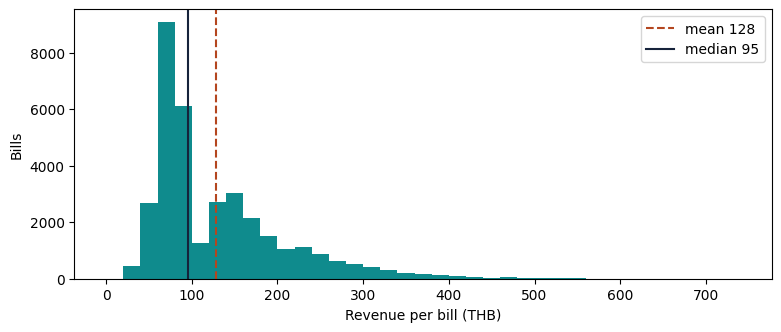

In [13]:
# ยอดต่อบิล: 1 บิล = รวมทุกแถวของ order_id เดียวกัน
bill = (pd.to_numeric(clean["qty"]) * pd.to_numeric(clean["unit_price"])).groupby(clean["order_id"]).sum()
print(f"ค่าเฉลี่ยต่อบิล  ฿{bill.mean():,.2f}")
print(f"ค่ากลางต่อบิล   ฿{bill.median():,.2f}")
print(f"90% ของบิลไม่เกิน ฿{bill.quantile(0.9):,.0f}")

import matplotlib.pyplot as plt
ax = bill.plot.hist(bins=range(0, 760, 20), color="#0F8B8D", figsize=(9, 3.5))
ax.axvline(bill.mean(), color="#B4461F", linestyle="--", label=f"mean {bill.mean():.0f}")
ax.axvline(bill.median(), color="#16233B", label=f"median {bill.median():.0f}")
ax.set_xlabel("Revenue per bill (THB)"); ax.set_ylabel("Bills"); ax.legend()
plt.show()
# หมายเหตุ: ใช้ป้ายภาษาอังกฤษ เพราะ matplotlib ใน Colab ไม่มีฟอนต์ไทย จะแสดงเป็นกล่องสี่เหลี่ยม

**คำถามชวนคิด:** ถ้าจะตั้งโปรฯ “ซื้อครบ X บาท รับส่วนลด” ควรใช้ค่าเฉลี่ยหรือค่ากลางเป็นฐาน และ X ควรเป็นเท่าไร


---
### 🚀 เสร็จเร็ว? ลองต่อ
- ให้ AI เขียนฟังก์ชัน `clean_sales(path)` ที่รวมทุกขั้น เรียกครั้งเดียวได้ไฟล์สะอาด (จะใช้ต่อในคาบ 7 ตอนทำ pipeline อัตโนมัติ)
- เพิ่มคอลัมน์ `date` และ `hour` ลงในข้อมูลสะอาด แล้วตรวจว่าไม่มีวันที่เลื่อนเพราะ timezone
- ลองอ่าน `customers.csv` แล้วทำ profiling ด้วย prompt เดิม มีปัญหาอะไรไหม